## Import Library

In [1]:
import platform

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                               AdaBoostClassifier, HistGradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import lightgbm as lgb
import xgboost as xgb
import sklearn

SEED = 42
np.random.seed(SEED)

print("=== FINGERPRINT REPRODUKSIBILITAS ===")
print(f"python : {platform.python_version()}")
print(f"numpy : {np.__version__}")
print(f"pandas : {pd.__version__}")
print(f"scikit-learn : {sklearn.__version__}")
print(f"lightgbm : {lgb.__version__}")
print(f"xgboost : {xgb.__version__}")
print(f"random seed: {SEED}")

=== FINGERPRINT REPRODUKSIBILITAS ===
python : 3.12.13
numpy : 2.0.2
pandas : 2.3.3
scikit-learn : 1.6.1
lightgbm : 4.6.0
xgboost : 3.2.0
random seed: 42


## Memuat Fitur & Split Data dari NB2

In [2]:
FEATURES_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/features_gold.csv"
SPLIT_PATH = "/kaggle/input/notebooks/kkndesalalatedzong/notebook02/split_assignment.csv"

features = pd.read_csv(FEATURES_PATH)
split = pd.read_csv(SPLIT_PATH)

train_paths = split.loc[split.split == "train", "path"]
val_paths = split.loc[split.split == "val", "path"]

print(f"Baris features_gold : {len(features)} ({features['path'].nunique()} eksekusi)")
print(f"train={len(train_paths)}, val={len(val_paths)}")

Baris features_gold : 59070 (1969 eksekusi)
train=1007, val=216


## Konfigurasi & Fungsi Prapemrosesan

In [3]:
SCREENING_CHECKPOINTS = [10, 20, 30] 

STORAGE_FEATURE_NAMES = ["T_s_r", "T_s_w", "V_s_r", "V_s_w", "H_s_w"]
MEMORY_FEATURE_NAMES = (
    ["H_m_w", "H_m_rw"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
ALL_FEATURE_NAMES = STORAGE_FEATURE_NAMES + MEMORY_FEATURE_NAMES
FEATURE_COLUMNS_FULL = ALL_FEATURE_NAMES + ["w"]

LOG1P_FEATURES = (
    ["T_s_r", "T_s_w", "V_s_r", "V_s_w"]
    + [f"C_4KB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_2MB_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"C_MMIO_{op}" for op in ["r", "w", "rw", "x"]]
    + [f"V_m_{op}" for op in ["r", "w", "rw", "x"]]
)
LOG1P_IDX = [FEATURE_COLUMNS_FULL.index(f) for f in LOG1P_FEATURES]


def build_sequences(df, paths, checkpoint_grid, feature_names):
    sub = df[df["path"].isin(paths) & df["window_s"].isin(checkpoint_grid)]
    sequences, labels = [], []
    for path, g in sub.groupby("path", sort=False):
        g = g.sort_values("window_s")
        assert len(g) == len(checkpoint_grid)
        w = g["window_s"].to_numpy(dtype="float64")
        feat = g[feature_names].to_numpy(dtype="float64")
        sequences.append(np.concatenate([feat, w[:, None]], axis=1))
        labels.append(int(g["is_ransomware"].iloc[0]))
    X = np.stack(sequences).astype("float32")
    y = np.array(labels, dtype="int32")
    return X, y


def apply_log1p(X, idx):
    X = X.copy()
    X[..., idx] = np.log1p(np.clip(X[..., idx], a_min=0.0, a_max=None))
    return X


def scale_3d(X, scaler):
    shp = X.shape
    return scaler.transform(X.reshape(-1, shp[-1])).reshape(shp).astype("float32")


X_train_raw, y_train = build_sequences(features, train_paths, SCREENING_CHECKPOINTS, ALL_FEATURE_NAMES)
X_val_raw, y_val = build_sequences(features, val_paths, SCREENING_CHECKPOINTS, ALL_FEATURE_NAMES)

X_train_log = apply_log1p(X_train_raw, LOG1P_IDX)
X_val_log = apply_log1p(X_val_raw, LOG1P_IDX)
scaler = StandardScaler().fit(X_train_log.reshape(-1, X_train_log.shape[-1]))
X_train = scale_3d(X_train_log, scaler)
X_val = scale_3d(X_val_log, scaler)

print(f"X_train {X_train.shape}, X_val {X_val.shape}")


X_train (1007, 3, 24), X_val (216, 3, 24)


## Define 11 Model

In [4]:
def make_models(seed):
    return {
        "Logistic Regression": LogisticRegression(random_state=seed),
        "LDA": LinearDiscriminantAnalysis(),
        "Gaussian Naive Bayes": GaussianNB(),
        "Decision Tree": DecisionTreeClassifier(random_state=seed),
        "Random Forest": RandomForestClassifier(random_state=seed),
        "Extra Trees": ExtraTreesClassifier(random_state=seed),
        "AdaBoost": AdaBoostClassifier(random_state=seed),
        "HistGradientBoosting": HistGradientBoostingClassifier(random_state=seed),
        "LightGBM": lgb.LGBMClassifier(random_state=seed, verbose=-1),
        "XGBoost": xgb.XGBClassifier(random_state=seed, eval_metric="logloss"),
        "SVM (linear)": SVC(kernel="linear", random_state=seed),
    }


def model_complexity(name, model):
    if name in ("Logistic Regression", "LDA", "SVM (linear)"):
        coef = np.asarray(model.coef_).ravel()
        intercept = np.asarray(model.intercept_).ravel()
        return "koefisien", int(coef.size + intercept.size)
    if name == "Gaussian Naive Bayes":
        return "parameter (mean+var per kelas per fitur)", int(model.theta_.size + model.var_.size)
    if name == "Decision Tree":
        return "node pohon", int(model.tree_.node_count)
    if name in ("Random Forest", "Extra Trees", "AdaBoost"):
        return "node pohon (total seluruh estimator)", int(sum(est.tree_.node_count for est in model.estimators_))
    if name == "HistGradientBoosting":
        return "iterasi boosting", int(model.n_iter_)
    if name == "LightGBM":
        return "jumlah pohon", int(model.booster_.num_trees())
    if name == "XGBoost":
        return "jumlah pohon", int(model.get_booster().num_boosted_rounds())
    raise ValueError(f"Aturan kompleksitas belum didefinisikan untuk: {name}")


print(f"{len(make_models(SEED))} algoritma terdaftar.")

11 algoritma terdaftar.


## Latih & Evaluasi 11 Model di 3 Checkpoint (10, 20, 30 Detik)

In [5]:
results = []
complexity_rows = []

for name, template in make_models(SEED).items():
    for i, w in enumerate(SCREENING_CHECKPOINTS):
        model = clone(template)
        Xw_train, Xw_val = X_train[:, i, :], X_val[:, i, :]
        model.fit(Xw_train, y_train)
        y_pred = model.predict(Xw_val)
        f1 = f1_score(y_val, y_pred, zero_division=0)
        results.append({"model": name, "window_s": w, "f1": f1})
        if w == SCREENING_CHECKPOINTS[-1]:
            satuan, ukuran = model_complexity(name, model)
            complexity_rows.append({"model": name, "satuan": satuan, "ukuran": ukuran})
    print(f"[{name}] selesai (3 checkpoint)")

results_df = pd.DataFrame(results)
complexity_df = pd.DataFrame(complexity_rows)
results_df.to_csv("/kaggle/working/nb3a_ml_screening_f1.csv", index=False)
complexity_df.to_csv("/kaggle/working/nb3a_ml_screening_complexity.csv", index=False)


[Logistic Regression] selesai (3 checkpoint)
[LDA] selesai (3 checkpoint)
[Gaussian Naive Bayes] selesai (3 checkpoint)
[Decision Tree] selesai (3 checkpoint)
[Random Forest] selesai (3 checkpoint)
[Extra Trees] selesai (3 checkpoint)
[AdaBoost] selesai (3 checkpoint)
[HistGradientBoosting] selesai (3 checkpoint)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] selesai (3 checkpoint)
[XGBoost] selesai (3 checkpoint)
[SVM (linear)] selesai (3 checkpoint)


## Ranking

In [6]:
print("F1 per model x checkpoint")
print(results_df.pivot(index="model", columns="window_s", values="f1").round(3)
      .sort_values(30, ascending=False).to_string())

ranking = (results_df[results_df.window_s == 30][["model", "f1"]]
           .merge(complexity_df, on="model")
           .sort_values("f1", ascending=False)
           .reset_index(drop=True))
ranking.index = ranking.index + 1
print("Peringkat berdasar F1 checkpoint 30 detik")
print(ranking.to_string())

F1 per model x checkpoint
window_s                 10     20     30
model                                    
Extra Trees           0.896  0.936  0.977
Random Forest         0.879  0.944  0.977
XGBoost               0.907  0.931  0.972
LightGBM              0.924  0.922  0.967
HistGradientBoosting  0.920  0.931  0.963
Decision Tree         0.821  0.830  0.931
AdaBoost              0.852  0.815  0.930
Logistic Regression   0.806  0.746  0.794
SVM (linear)          0.818  0.737  0.790
LDA                   0.787  0.716  0.763
Gaussian Naive Bayes  0.738  0.728  0.706
Peringkat berdasar F1 checkpoint 30 detik
                   model        f1                                    satuan  ukuran
1            Extra Trees  0.976959      node pohon (total seluruh estimator)   44958
2          Random Forest  0.976526      node pohon (total seluruh estimator)   13768
3                XGBoost  0.972222                              jumlah pohon     100
4               LightGBM  0.967136            

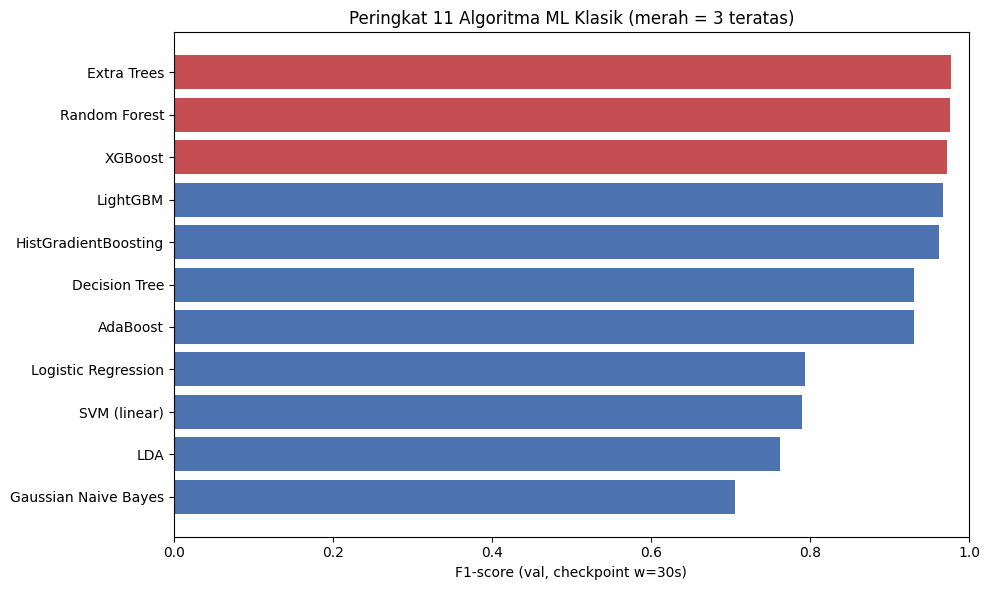

In [7]:
order = ranking["model"].tolist()
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#C44E52" if i < 3 else "#4C72B0" for i in range(len(order))]
ax.barh(order[::-1], ranking.set_index("model").loc[order[::-1], "f1"], color=colors[::-1])
ax.set_xlabel("F1-score (val, checkpoint w=30s)")
ax.set_title("Peringkat 11 Algoritma ML Klasik (merah = 3 teratas)")
ax.set_xlim(0, 1.0)
plt.tight_layout()
plt.show()
